<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/07_aNN_Cero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [183]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import scipy as sc
import matplotlib.pylab as plt

In [185]:
class layer_nn():
  """
  Definición de la capas de la red neuronal 
  e inicializacion de parametros. 
  """

  def __init__(self,act_fun, n_layer_present, n_layer_before ):    
    self.W = 2*np.random.random((n_layer_before,n_layer_present)) - 1
    self.B = 2*np.random.random((n_layer_present,1)) - 1
    self.act_fun = act_fun

  def output(self, Z,A, Ap):
    self.Z = Z
    self.A = A
    self.Ap = Ap

  def derivates(self, dW, db):
    self.dW = dW
    self.db = db

@np.vectorize
def relu(x):
  if(x>=0):
    return x
  else :
    return 0

@np.vectorize
def reluP(x):
  if(x>=0):
    return 1
  else :
    return 0

def sigmoide(x):      
  f= lambda x: 1/(1+np.exp(-x))
  return f(x)

def act_function(x, activation):        
    if activation == "sigmoid":
        f = sigmoide(x)
        fp = sigmoide(x)*(1-sigmoide(x))
    elif activation == "tanh":
        f = lambda x: np.tanh(x)

    elif activation == "relu":
        f = relu(x)
        fp = reluP(x)
    
    return f, fp
    

def forward_pass(input, nn_red):
  A0 = input  
  nn_red_update = []
  
  for layer in nn_red: 
    Z = layer.W.T@A0 + layer.B    
    A, Ap = act_function(Z, layer.act_fun)        
    layer.output(Z, A, Ap)    
    nn_red_update.append(layer)
    A0 = A        
  return A, nn_red_update


def cost_Function(A, Y):
  m = Y.shape[0]
  m_ = 1/m
  cost = Y*np.log(A)+(1-Y)*np.log(1-A)
  cost = -m_*cost.sum()
  return cost

def backward_propagation(AL,Y,nn):
  L = len(nn) - 1
  
  dAL = -(np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
  fp = nn[L].Ap 
  dZ = dAL*fp  
  m_ = 1/np.shape(Y)[0]

  dW_L = m_*dZ@nn[L-1].Ap.T
  db_L = m_*np.sum(dZ, axis=1, keepdims=True)

  nn[L].dW=dW_L
  nn[L].db=db_L

  dAL_1 = np.dot(nn[L].W, dZ)

  for l in reversed(range(1,L)):
#    dAL_1 = dAL 
    fp = nn[l].Ap
    dZ_1 = dAL_1*fp
    dW_L1 = m_*dZ_1@nn[l-1].Ap.T
    db_L1 = m_*np.sum(dZ_1, axis=1, keepdims=True)
    
   # dAL = dAL_1.copy()
    
    nn[l].dW=dW_L1
    nn[l].db=db_L1
    dAL_1 = np.dot(nn[l].W,dZ_1)
  return nn


def update_params(nn, learning_rate):  
  L=len(nn)
  for l in range(1, L):    
    nn[l].W = nn[l].W - learning_rate*nn[l].dW.T  
    nn[l].B = nn[l].B - learning_rate*nn[l].db
  return nn

def red_neuronal(topology, act_fn):
  nn_red = []
  L = len(topology)
  for i in range(1, L):  
    nn_red.append(layer_nn(act_fn[i],topology[i],topology[i-1] ) )  
  return nn_red


In [188]:
n_x = 16*16
topology = [n_x,16,8,4,1]
act_fn   = [None,"relu", "relu", "relu","sigmoid" ]

nn_red = red_neuronal(topology, act_fn)
A0 = x_train_.T
Y = np.array(train_label)

A, nn = forward_pass(A0, nn_red)
J = cost_Function(A, np.array(train_label))
j = []
j.append(J)

for i in range(1,500):

  nn = backward_propagation(A, Y, nn)
  nn = update_params(nn, 0.001)
  A, nn = forward_pass(A0, nn)

  J = cost_Function(A, np.array(train_label))
  j.append(J)


/var/folders/6s/h5hh29jn1dqd4r627s043vy40000gn/T/ipykernel_65679/1503533124.py:69: RuntimeWarning: divide by zero encountered in log
  cost = Y*np.log(A)+(1-Y)*np.log(1-A)
/var/folders/6s/h5hh29jn1dqd4r627s043vy40000gn/T/ipykernel_65679/1503533124.py:69: RuntimeWarning: invalid value encountered in multiply
  cost = Y*np.log(A)+(1-Y)*np.log(1-A)
/var/folders/6s/h5hh29jn1dqd4r627s043vy40000gn/T/ipykernel_65679/1503533124.py:76: RuntimeWarning: invalid value encountered in divide
  dAL = -(np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))


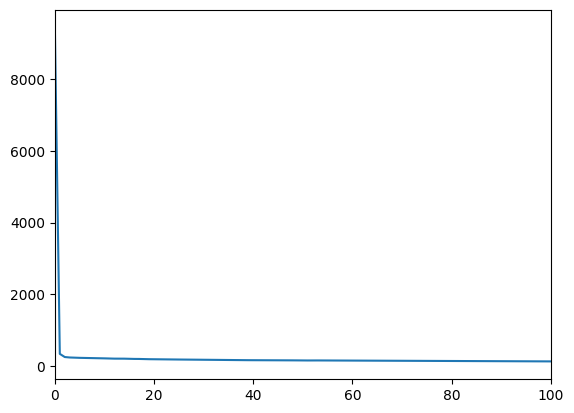

In [182]:
plt.figure()
plt.plot(j)
plt.xlim(0, 100)
plt.show()

In [150]:
out = (A<0.5)*1.0
ones_nn = (out*1==1)
Y_nn = (Y==1)
zeros_nn = (out*1==0)
Y_nn = (Y==0)
print((Y_nn==zeros_nn).sum()*100/len(Y_nn))
print((Y_nn==ones_nn).sum()*100/len(Y_nn))

40000.0
40000.0
